In [126]:
import pandas as pd

In [127]:
dataset = pd.read_csv('Salary_Data.csv')

In [128]:
X = dataset.drop(columns=['Salary'])
y = dataset['Salary']

In [129]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [130]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=6)
poly.fit(X_train)
Xpoly_train = poly.transform(X_train)

In [131]:
from sklearn.linear_model import LinearRegression
poly_r = LinearRegression()
poly_r.fit(Xpoly_train,y_train)

LinearRegression()

In [132]:
Xpoly_test = poly.transform(X_test)
y_pred = poly_r.predict(Xpoly_test)

In [133]:
# 학습데이터 Xpoly_train에 대한 예측값
y_train_pred = poly_r.predict(Xpoly_train)

In [134]:
from sklearn.metrics import r2_score
print('Train R2: ',r2_score(y_train,y_train_pred))
print('Test R2 : ',r2_score(y_test,y_pred))

Train R2:  0.9738639029446283
Test R2 :  0.9125361954485954


- degree 값을 조정하여, training data와 test data에 대한 성능 비교를 통해 overfitting과 underfitting을 확인할 수 있다.

## 시각화
- `numpy`: 수학(벡터, 행렬 등 포함)을 다루는 라이브러리
- `np.arange(a,b,c)`: a부터 b까지 c간격으로 값 생성 (b 값은 제외)
- `reshape(-1,1)`: 2차원 array로 변환

In [135]:
import numpy as np
import matplotlib.pyplot as plt
# model의 예측값을 시각화 하기 위한 X 기준 값
X_sample = np.arange(1.1,10.6,0.05).reshape(-1,1)
Xpoly_sample = poly.transform(X_sample)
sample_pred = poly_r.predict(Xpoly_sample)
# 경력 1.1부터 10.55까지 값(X_sample)에 대한 예측값(sample_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


- `plt.scatter(X,Y)`: (x,y) 좌표에 마커를 표시
- `plt.plot(X,Y)`: (x,y) 좌표를 이은 선차트 표시

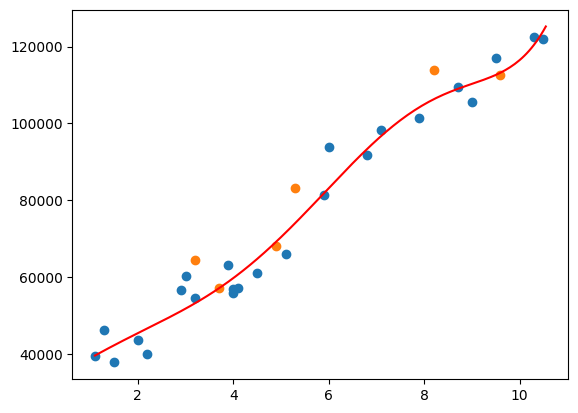

In [136]:
# 1. 학습 및 테스트 데이터 시각화
plt.scatter(X_train,y_train) # 학습데이터
plt.scatter(X_test,y_test)   # 검증용 데이터
plt.plot(X_sample,sample_pred,color='red') # 모델의 예측값